In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
# Download dataset using kagglehub
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("mdwasimakhtar03/social-network-adscsv")

print("Dataset folder path:", path)

# List files inside the downloaded folder
print("\nFiles inside dataset folder:")
print(os.listdir(path))

# Load dataset using full path
file_path = os.path.join(path, "Social_Network_Ads.csv")

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

/Users/bhumikajawale/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/bhumikajawale/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset folder path: /Users/bhumikajawale/.cache/kagglehub/datasets/mdwasimakhtar03/social-network-adscsv/versions/1

Files inside dataset folder:
['Social_Network_Ads.csv']

Dataset loaded successfully!
Shape: (400, 3)

First 5 rows:
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [3]:
# Selecting independent variables (Age and EstimatedSalary)
X = df[['Age', 'EstimatedSalary']]

# Selecting dependent variable
y = df['Purchased']

print("\nIndependent Variables (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())


Independent Variables (X):
   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000

Target Variable (y):
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


In [4]:
# Splitting dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (300, 2)
Testing samples: (100, 2)


In [5]:
# Feature scaling improves logistic regression performance
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [6]:
# 0 User will NOT purchase the product
# 1	User WILL purchase the product

In [7]:
# Create logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
# Testing the trained logistic regression model using test dataset

# Predict values for test dataset
y_pred = model.predict(X_test)

print("Predicted values for test dataset:")
print(y_pred)

print("\nActual values:")
print(y_test.values)

Predicted values for test dataset:
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1]

Actual values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


In [9]:
# Create comparison table
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted Results:")
print(results.head(10))


Actual vs Predicted Results:
     Actual  Predicted
132       0          0
309       0          0
341       0          0
196       0          0
246       0          0
60        0          0
155       0          0
261       1          1
141       0          0
214       0          1


/Users/bhumikajawale/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


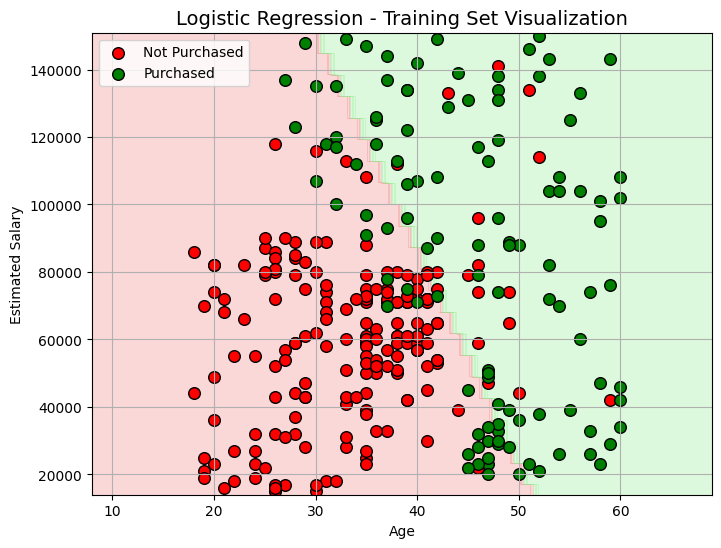

In [10]:
# Better visualization for Logistic Regression Training Set

from matplotlib.colors import ListedColormap
plt.figure(figsize=(8,6))

X_set, y_set = sc.inverse_transform(X_train), y_train

# Create mesh grid
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:,0].min()-10, stop = X_set[:,0].max()+10, step=1),
    np.arange(start = X_set[:,1].min()-1000, stop = X_set[:,1].max()+1000, step=100)
)

# Plot decision boundary
plt.contourf(
    X1, X2,
    model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(('lightcoral','lightgreen'))
)

# Plot actual points
colors = ['red','green']
labels = ['Not Purchased','Purchased']

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=colors[i],
        label=labels[i],
        edgecolor='black',
        s=70
    )

plt.title("Logistic Regression - Training Set Visualization", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Light Red	User will NOT purchase (Class = 0)
# Light Green	User WILL purchase (Class = 1)
# So if a new user falls inside a green region, the model predicts Purchased.